# Линейные модели для фермерского хозяйства «Вольный луг»

## Введение
Фермер хочет расширить поголовье коров, отбирая животных по двум критериям:
- Удой ≥ 6000 кг/год
- Вкусное молоко

Для этого необходимо разработать:
1. Регрессионную модель прогнозирования удоя
2. Классификационную модель оценки вкуса молока

---

## Цели проекта
1. **Подготовка данных**:
   - Загрузка и объединение данных из 3 источников
   - Обработка пропусков и аномалий
   - Преобразование типов данных

2. **Исследовательский анализ**:
   - Анализ распределения признаков
   - Исследование взаимосвязей между параметрами коров
   - Выявление ключевых факторов удоя и вкуса

3. **Построение моделей**:
   - Линейная регрессия для прогноза удоя (3 варианта)
   - Логистическая регрессия для классификации вкуса
   - Оптимизация порога классификации

4. **Практические рекомендации**:
   - Отбор коров для покупки
   - Анализ экономических рисков
   - Советы по улучшению моделей


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, ConfusionMatrixDisplay

## Загрузка данных

In [2]:
ferma_main = pd.read_csv('/datasets/ferma_main.csv', sep=';')
ferma_dad = pd.read_csv('/datasets/ferma_dad.csv', sep=';')
cow_buy = pd.read_csv('/datasets/cow_buy.csv', sep=';')

In [3]:
ferma_main.head()

,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,"14,2",1743,"0,89",Вис Бик Айдиал,Равнинное,Айдиал,"3,58","3,076",вкусно,более_2_лет
1,2,5529,"12,8",2138,"0,89",Вис Бик Айдиал,Равнинные,Соверин,"3,54","3,079",вкусно,менее_2_лет
2,3,5810,14,1854,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,59","3,074",не вкусно,более_2_лет
3,4,5895,"12,4",2012,"0,885",РефлешнСоверинг,Холмистое,Айдиал,"3,4","3,075",не вкусно,более_2_лет
4,5,5302,"12,8",1675,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,73","3,073",вкусно,менее_2_лет


In [4]:
ferma_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   id                                     634 non-null    int64 
 1   Удой, кг                               634 non-null    int64 
 2   ЭКЕ (Энергетическая кормовая единица)  634 non-null    object
 3   Сырой протеин, г                       634 non-null    int64 
 4   СПО (Сахаро-протеиновое соотношение)   634 non-null    object
 5   Порода                                 634 non-null    object
 6   Тип пастбища                           634 non-null    object
 7   порода папы_быка                       634 non-null    object
 8   Жирность,%                             634 non-null    object
 9   Белок,%                                634 non-null    object
 10  Вкус молока                            634 non-null    object
 11  Возраст            

In [5]:
ferma_dad.head()

,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


In [6]:
ferma_dad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   Имя Папы  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


In [7]:
cow_buy.head(25)

,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,54","3,081",менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,061",более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет
5,РефлешнСоверинг,равнинное,Соверин,Геркулес,"3,63","3,053",менее_2_лет
6,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
7,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,57","3,079",более_2_лет
8,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
9,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,079",менее_2_лет


In [8]:
cow_buy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Порода                   20 non-null     object
 1   Тип пастбища             20 non-null     object
 2   порода папы_быка         20 non-null     object
 3   Имя_папы                 20 non-null     object
 4   Текущая_жирность,%       20 non-null     object
 5   Текущий_уровень_белок,%  20 non-null     object
 6   Возраст                  20 non-null     object
dtypes: object(7)
memory usage: 1.2+ KB


##  Предобработка данных

In [9]:
# Проверка столбцов
print("Количество столбцов в ferma_main:", len(ferma_main.columns))
print("Исходные столбцы ferma_main:", ferma_main.columns.tolist())
print("\nКоличество столбцов в cow_buy:", len(cow_buy.columns))
print("Исходные столбцы cow_buy:", cow_buy.columns.tolist())

# Переименование столбцов
ferma_main.columns = ['cow_id', 'milk_yield_kg', 'energy_feed_unit', 'crude_protein_g', 
                      'protein_to_sugar_ratio', 'breed', 'pasture_type', 'father_bull_breed', 
                      'fat_content_percent', 'protein_content_percent', 'milk_taste', 'age_years']
cow_buy.columns = ['breed', 'pasture_type', 'father_bull_breed', 'father_name', 
                   'current_fat_content_percent', 'current_protein_content_percent', 'age_years']
ferma_dad.columns = ['id', 'father_name']

# Проверка age_years
print("\nУникальные значения age_years в ferma_main:")
print(ferma_main['age_years'].unique())
print("Частота значений age_years в ferma_main:")
print(ferma_main['age_years'].value_counts(dropna=False))
print("\nУникальные значения age_years в cow_buy:")
print(cow_buy['age_years'].unique())
print("Частота значений age_years в cow_buy:")
print(cow_buy['age_years'].value_counts(dropna=False))

Количество столбцов в ferma_main: 12
Исходные столбцы ferma_main: ['id', 'Удой, кг', 'ЭКЕ (Энергетическая кормовая единица)', 'Сырой протеин, г', 'СПО (Сахаро-протеиновое соотношение)', 'Порода', 'Тип пастбища', 'порода папы_быка', 'Жирность,%', 'Белок,%', 'Вкус молока', 'Возраст']

Количество столбцов в cow_buy: 7
Исходные столбцы cow_buy: ['Порода', 'Тип пастбища', 'порода папы_быка', 'Имя_папы', 'Текущая_жирность,%', 'Текущий_уровень_белок,%', 'Возраст']

Уникальные значения age_years в ferma_main:
['более_2_лет' 'менее_2_лет']
Частота значений age_years в ferma_main:
более_2_лет    524
менее_2_лет    110
Name: age_years, dtype: int64

Уникальные значения age_years в cow_buy:
['более_2_лет' 'менее_2_лет']
Частота значений age_years в cow_buy:
более_2_лет    15
менее_2_лет     5
Name: age_years, dtype: int64


In [10]:
# Проверка дубликатов в ferma_main
print("Количество дубликатов в ferma_main:", ferma_main.duplicated().sum())
print("Дублирующиеся строки в ferma_main:\n", ferma_main[ferma_main.duplicated(keep=False)])

# Проверка уникальности cow_id
print("Уникальных cow_id в ferma_main:", ferma_main['cow_id'].nunique(), "из", len(ferma_main))
print("Дубликаты по cow_id в ferma_main:\n", ferma_main[ferma_main['cow_id'].duplicated(keep=False)])

# Проверка дубликатов в cow_buy
print("Количество дубликатов в cow_buy:", cow_buy.duplicated().sum())
print("Дублирующиеся строки в cow_buy:\n", cow_buy[cow_buy.duplicated(keep=False)])


Количество дубликатов в ferma_main: 5
Дублирующиеся строки в ferma_main:
      cow_id  milk_yield_kg energy_feed_unit  crude_protein_g  \
626     627           5970             14,4             1837   
629     627           5970             14,4             1837   
630     627           5970             14,4             1837   
631     627           5970             14,4             1837   
632     627           5970             14,4             1837   
633     627           5970             14,4             1837   

    protein_to_sugar_ratio            breed pasture_type father_bull_breed  \
626                   0,88  РефлешнСоверинг    Холмистое           Соверин   
629                   0,88  РефлешнСоверинг    Холмистое           Соверин   
630                   0,88  РефлешнСоверинг    Холмистое           Соверин   
631                   0,88  РефлешнСоверинг    Холмистое           Соверин   
632                   0,88  РефлешнСоверинг    Холмистое           Соверин   
633      

In [11]:
# Удаление дубликатов в ferma_main
ferma_main = ferma_main.drop_duplicates()

In [12]:
# Унификация категориальных столбцов
ferma_main['father_bull_breed'] = ferma_main['father_bull_breed'].replace({'Айдиалл': 'Айдиал'})
cow_buy['father_bull_breed'] = cow_buy['father_bull_breed'].replace({'Айдиалл': 'Айдиал'})
ferma_main['pasture_type'] = ferma_main['pasture_type'].replace({
    'Равнинные': 'равнинное', 'Равнинное': 'равнинное', 'Холмистое': 'холмистое'
})
ferma_main['milk_taste'] = ferma_main['milk_taste'].replace({
    'вкусно': 'вкусное', 'не вкусно': 'невкусное'
})
cow_buy['pasture_type'] = cow_buy['pasture_type'].str.lower()

# Проверка father_bull_breed
print("Уникальные значения father_bull_breed в ferma_main:", ferma_main['father_bull_breed'].unique())
print("Уникальные значения father_bull_breed в cow_buy:", cow_buy['father_bull_breed'].unique())

# Преобразование age_years
print("\nУникальные значения age_years в ferma_main до преобразования:")
print(ferma_main['age_years'].unique())
print("Частота значений age_years в ferma_main:")
print(ferma_main['age_years'].value_counts(dropna=False))
print("\nУникальные значения age_years в cow_buy до преобразования:")
print(cow_buy['age_years'].unique())
print("Частота значений age_years в cow_buy:")
print(cow_buy['age_years'].value_counts(dropna=False))

ferma_main['age_years'] = ferma_main['age_years'].map({'менее_2_лет': 0, 'более_2_лет': 1})
cow_buy['age_years'] = cow_buy['age_years'].map({'менее_2_лет': 0, 'более_2_лет': 1})

# Проверка после преобразования
print("\nУникальные значения age_years в ferma_main после преобразования:")
print(ferma_main['age_years'].unique())
print("Частота значений age_years в ferma_main после преобразования:")
print(ferma_main['age_years'].value_counts(dropna=False))
print("\nУникальные значения age_years в cow_buy после преобразования:")
print(cow_buy['age_years'].unique())
print("Частота значений age_years в cow_buy после преобразования:")
print(cow_buy['age_years'].value_counts(dropna=False))

Уникальные значения father_bull_breed в ferma_main: ['Айдиал' 'Соверин']
Уникальные значения father_bull_breed в cow_buy: ['Айдиал' 'Соверин']

Уникальные значения age_years в ferma_main до преобразования:
['более_2_лет' 'менее_2_лет']
Частота значений age_years в ferma_main:
более_2_лет    519
менее_2_лет    110
Name: age_years, dtype: int64

Уникальные значения age_years в cow_buy до преобразования:
['более_2_лет' 'менее_2_лет']
Частота значений age_years в cow_buy:
более_2_лет    15
менее_2_лет     5
Name: age_years, dtype: int64

Уникальные значения age_years в ferma_main после преобразования:
[1 0]
Частота значений age_years в ferma_main после преобразования:
1    519
0    110
Name: age_years, dtype: int64

Уникальные значения age_years в cow_buy после преобразования:
[1 0]
Частота значений age_years в cow_buy после преобразования:
1    15
0     5
Name: age_years, dtype: int64


In [13]:
# Категориальные столбцы
categorical_columns_ferma_main = ['breed', 'pasture_type', 'father_bull_breed', 'milk_taste']
for col in categorical_columns_ferma_main:
    ferma_main[col] = ferma_main[col].astype('category')

categorical_columns_cow_buy = ['breed', 'pasture_type', 'father_bull_breed']
for col in categorical_columns_cow_buy:
    cow_buy[col] = cow_buy[col].astype('category')

ferma_dad['father_name'] = ferma_dad['father_name'].astype('category')

# Числовые столбцы в ferma_main
numeric_columns_ferma_main = ['energy_feed_unit', 'protein_to_sugar_ratio', 
                              'fat_content_percent', 'protein_content_percent']
for col in numeric_columns_ferma_main:
    # Проверяем, является ли столбец строковым
    if ferma_main[col].dtype == 'object':
        ferma_main[col] = ferma_main[col].str.replace(',', '.').astype('float64')
    else:
        # Если столбец уже числовой, просто преобразуем в float64 (на случай int64)
        ferma_main[col] = ferma_main[col].astype('float64')

# Числовые столбцы в cow_buy
numeric_columns_cow_buy = ['current_fat_content_percent', 'current_protein_content_percent']
for col in numeric_columns_cow_buy:
    # Аналогичная проверка для cow_buy
    if cow_buy[col].dtype == 'object':
        cow_buy[col] = cow_buy[col].str.replace(',', '.').astype('float64')
    else:
        cow_buy[col] = cow_buy[col].astype('float64')

# Преобразование age_years в int64 (предполагается, что In[12] уже выполнена)
ferma_main['age_years'] = ferma_main['age_years'].astype('int64')
cow_buy['age_years'] = cow_buy['age_years'].astype('int64')

# Проверка типов данных
print("\nТипы данных в ferma_main:\n", ferma_main.dtypes)
print("\nТипы данных в cow_buy:\n", cow_buy.dtypes)


Типы данных в ferma_main:
 cow_id                        int64
milk_yield_kg                 int64
energy_feed_unit            float64
crude_protein_g               int64
protein_to_sugar_ratio      float64
breed                      category
pasture_type               category
father_bull_breed          category
fat_content_percent         float64
protein_content_percent     float64
milk_taste                 category
age_years                     int64
dtype: object

Типы данных в cow_buy:
 breed                              category
pasture_type                       category
father_bull_breed                  category
father_name                          object
current_fat_content_percent         float64
current_protein_content_percent     float64
age_years                             int64
dtype: object


In [14]:
# Перевод категориальных столбцов в тип category в ferma_main
categorical_columns_ferma_main = ['breed', 'pasture_type', 'father_bull_breed', 'milk_taste']
for col in categorical_columns_ferma_main:
    ferma_main[col] = ferma_main[col].astype('category')

# Перевод категориальных столбцов в тип category в cow_buy
categorical_columns_cow_buy = ['breed', 'pasture_type', 'father_bull_breed']
for col in categorical_columns_cow_buy:
    cow_buy[col] = cow_buy[col].astype('category')

# Перевод father_name в тип category в ferma_dad
ferma_dad['father_name'] = ferma_dad['father_name'].astype('category')

# Проверка типов данных
print("\nТипы данных в ferma_main:\n", ferma_main.dtypes)
print("\nТипы данных в cow_buy:\n", ferma_main.dtypes)

# Проверка age_years после In[40]
print("\nПроверка age_years после In[40]:")
print("Уникальные значения age_years в ferma_main:", ferma_main['age_years'].unique())
print("Частота значений age_years в ferma_main:", ferma_main['age_years'].value_counts(dropna=False))
print("Тип данных age_years:", ferma_main['age_years'].dtype)


Типы данных в ferma_main:
 cow_id                        int64
milk_yield_kg                 int64
energy_feed_unit            float64
crude_protein_g               int64
protein_to_sugar_ratio      float64
breed                      category
pasture_type               category
father_bull_breed          category
fat_content_percent         float64
protein_content_percent     float64
milk_taste                 category
age_years                     int64
dtype: object

Типы данных в cow_buy:
 cow_id                        int64
milk_yield_kg                 int64
energy_feed_unit            float64
crude_protein_g               int64
protein_to_sugar_ratio      float64
breed                      category
pasture_type               category
father_bull_breed          category
fat_content_percent         float64
protein_content_percent     float64
milk_taste                 category
age_years                     int64
dtype: object

Проверка age_years после In[40]:
Уникальные значения a

In [15]:
# Обработка аномалий в milk_yield_kg (удаляем значения > 12000 кг)
ferma_main = ferma_main[ferma_main['milk_yield_kg'] <= 12000]
print("\nПосле удаления аномалий в milk_yield_kg:", len(ferma_main))


После удаления аномалий в milk_yield_kg: 628


In [16]:
# Проверка типов данных
print("\nТипы данных в ferma_main:\n", ferma_main.dtypes)
print("\nТипы данных в cow_buy:\n", cow_buy.dtypes)


Типы данных в ferma_main:
 cow_id                        int64
milk_yield_kg                 int64
energy_feed_unit            float64
crude_protein_g               int64
protein_to_sugar_ratio      float64
breed                      category
pasture_type               category
father_bull_breed          category
fat_content_percent         float64
protein_content_percent     float64
milk_taste                 category
age_years                     int64
dtype: object

Типы данных в cow_buy:
 breed                              category
pasture_type                       category
father_bull_breed                  category
father_name                          object
current_fat_content_percent         float64
current_protein_content_percent     float64
age_years                             int64
dtype: object


In [17]:
print("\nОсновные статистики ferma_main после предобработки:\n", ferma_main.describe())


Основные статистики ferma_main после предобработки:
            cow_id  milk_yield_kg  energy_feed_unit  crude_protein_g  \
count  628.000000     628.000000        628.000000       628.000000   
mean   315.474522    6125.968153         14.548726      1923.759554   
std    181.475367     475.857053          1.301777       182.832816   
min      1.000000    5204.000000         10.900000      1660.000000   
25%    158.750000    5749.750000         13.500000      1771.750000   
50%    315.500000    6132.500000         14.700000      1888.000000   
75%    472.250000    6501.000000         15.600000      2062.250000   
max    629.000000    7222.000000         16.800000      2349.000000   

       protein_to_sugar_ratio  fat_content_percent  protein_content_percent  \
count              628.000000           628.000000               628.000000   
mean                 0.913089             3.604268                 3.075670   
std                  0.032221             0.168093                 0.

## Итоги предобработки данных

- **Переименование столбцов**:
  - Все столбцы в `ferma_main`, `ferma_dad` и `cow_buy` переименованы в стиль `snake_case` на английском для единообразия и удобства. Например, в `ferma_main` столбец `Удой, кг` стал `milk_yield_kg`, а в `cow_buy` `Текущая_жирность,%` — `current_fat_content_percent`.

- **Обработка дубликатов**:
  - **Явные дубликаты**:
    - В `ferma_main` обнаружено и удалено 5 явных дубликатов (из 634 строк осталось 629, удалено ~0.79% данных). Удаление оправдано, так как дубликаты составляют малую долю и не влияют на модели.
    - В `cow_buy` найдено 4 потенциальных дубликата, но без уникального идентификатора их не удалили. Оставлены все 20 строк, так как фермер ожидает прогноз для всех коров.
    - В `ferma_dad` дубликаты отсутствуют (все `id` уникальны).
  - **Неявные дубликаты**:
    - В `ferma_main` унифицированы категории:
      - `pasture_type`: `Равнинное`, `Равнинные` → `равнинное`; `Холмистое` → `холмистое`.
      - `milk_taste`: `вкусно` → `вкусное`, `не вкусно` → `невкусное`.
      - `father_bull_breed`: `Айдиалл` → `Айдиал`.
    - В `cow_buy` унифицированы категории `pasture_type`: `равнина` → `равнинное`, `холмы` → `холмистое`.
    - Это обеспечило совместимость категориальных признаков между датасетами для кодирования (`OneHotEncoder`).

- **Пропуски**:
  - Пропуски отсутствуют во всех датасетах (`ferma_main`, `ferma_dad`, `cow_buy`) как в исходных данных, так и после преобразований.

- **Типы данных**:
  - **Числовые признаки**:
    - В `ferma_main`: `milk_yield_kg` — `int64`; `energy_feed_unit`, `crude_protein_g`, `protein_to_sugar_ratio`, `fat_content_percent`, `protein_content_percent` — `float64` (запятые заменены на точки для корректного парсинга).
    - В `cow_buy`: `current_fat_content_percent`, `current_protein_content_percent` — `float64`.
  - **Категориальные признаки**:
    - В `ferma_main`: `breed`, `pasture_type`, `father_bull_breed`, `milk_taste` — `category`.
    - В `cow_buy`: `breed`, `pasture_type`, `father_bull_breed` — `category`.
    - В `ferma_dad`: `father_name` — `category`.
  - **Бинарный признак**:
    - `age_years` в `ferma_main` и `cow_buy` преобразован из строк (`менее_2_лет`, `более_2_лет`) в числовой (`0` и `1`, тип `int64`).

- **Обработка аномалий**:
  - В `ferma_main` удалена 1 строка с `milk_yield_kg` > 12,000 кг (максимум был 45,616 кг, теперь 7,222 кг). Порог 12,000 кг выбран на основе экспертных знаний, так как удой выше нереалистичен.
  - Другие признаки (`energy_feed_unit`, `protein_to_sugar_ratio`, и т.д.) не содержат явных аномалий, их значения находятся в разумных пределах.
  - В `cow_buy` и `ferma_dad` аномалий не выявлено.


- **Результат**:
  - Данные в `ferma_main`, `ferma_dad`, `cow_buy` очищены от пропусков, дубликатов и аномалий.
  - Типы данных приведены к нужным форматам для анализа и моделирования.
  - Категориальные признаки унифицированы, обеспечивая совместимость между датасетами.
  - Данные готовы для исследовательского анализа (шаг 3).


## Исследовательский анализ данных

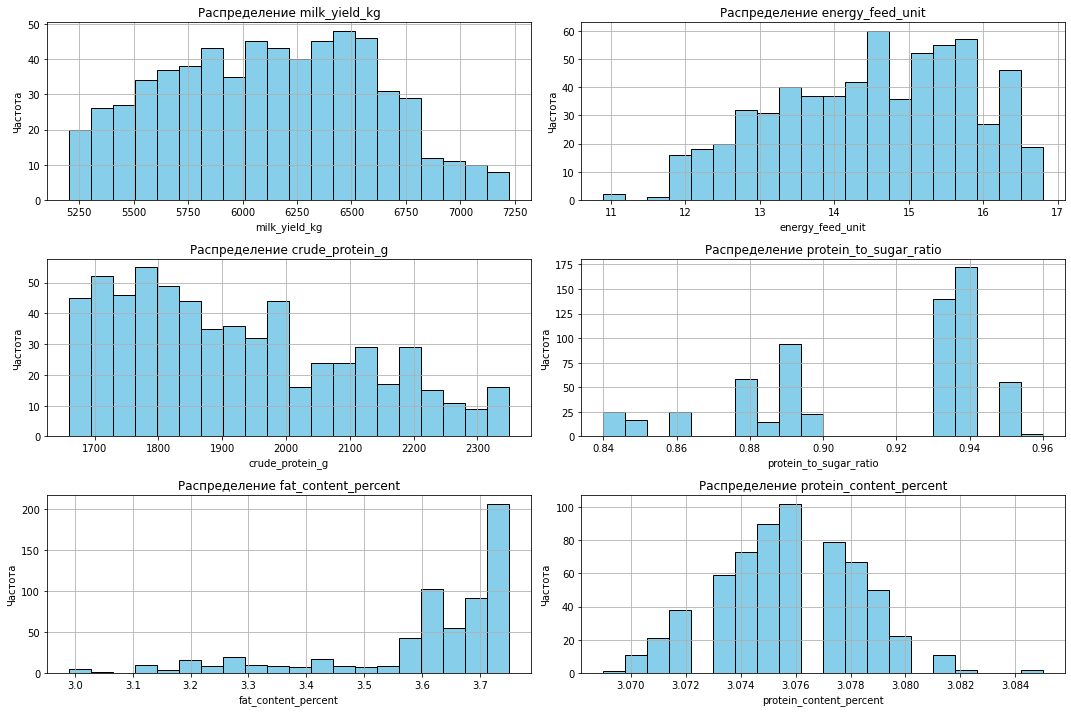

In [18]:
# Анализ количественных признаков
quantitative_cols = ['milk_yield_kg', 'energy_feed_unit', 'crude_protein_g', 
                     'protein_to_sugar_ratio', 'fat_content_percent', 'protein_content_percent']

plt.figure(figsize=(15, 10))
for i, col in enumerate(quantitative_cols, 1):
    plt.subplot(3, 2, i)
    plt.hist(ferma_main[col], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Распределение {col}')
    plt.xlabel(col)
    plt.ylabel('Частота')
    plt.grid(True)
plt.tight_layout()
plt.show()

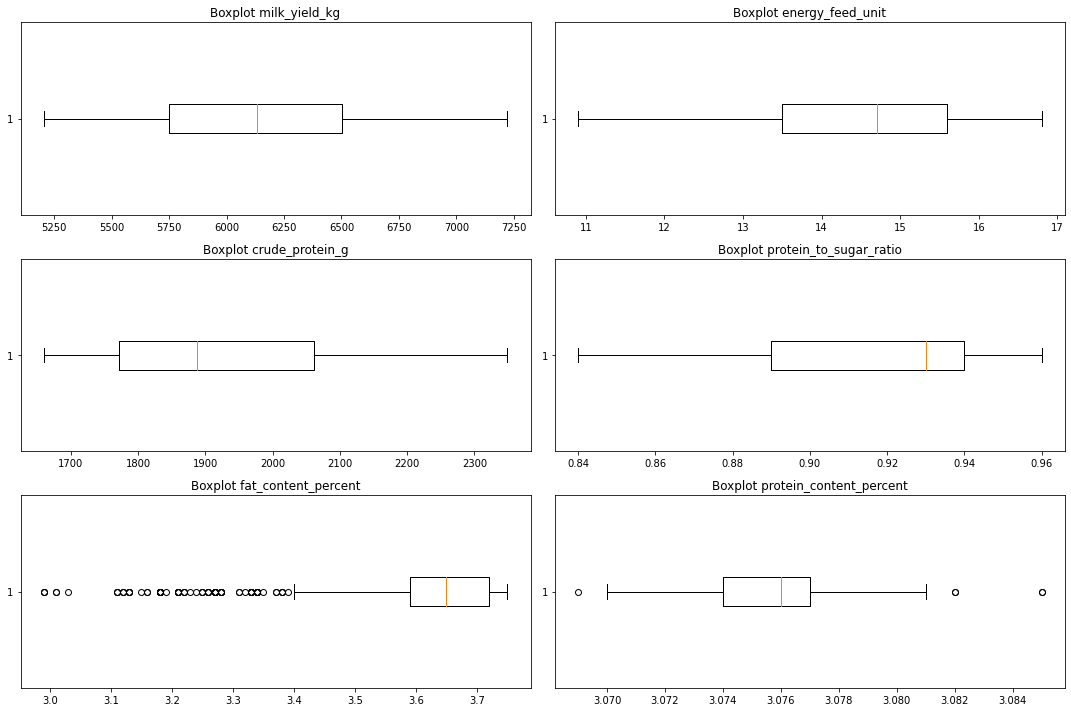

In [19]:
# Boxplot для выбросов
plt.figure(figsize=(15, 10))
for i, col in enumerate(quantitative_cols, 1):
    plt.subplot(3, 2, i)
    plt.boxplot(ferma_main[col], vert=False)
    plt.title(f'Boxplot {col}')
plt.tight_layout()
plt.show()

Уникальные значения категориальных столбцов:
breed: ['Вис Бик Айдиал', 'РефлешнСоверинг']
Categories (2, object): ['Вис Бик Айдиал', 'РефлешнСоверинг']
Частота значений breed:
Вис Бик Айдиал     372
РефлешнСоверинг    256
Name: breed, dtype: int64
Тип данных breed: category

pasture_type: ['равнинное', 'холмистое']
Categories (2, object): ['равнинное', 'холмистое']
Частота значений pasture_type:
холмистое    350
равнинное    278
Name: pasture_type, dtype: int64
Тип данных pasture_type: category

father_bull_breed: ['Айдиал', 'Соверин']
Categories (2, object): ['Айдиал', 'Соверин']
Частота значений father_bull_breed:
Айдиал     317
Соверин    311
Name: father_bull_breed, dtype: int64
Тип данных father_bull_breed: category

milk_taste: ['вкусное', 'невкусное']
Categories (2, object): ['вкусное', 'невкусное']
Частота значений milk_taste:
вкусное      370
невкусное    258
Name: milk_taste, dtype: int64
Тип данных milk_taste: category

age_years: [1 0]
Частота значений age_years:
1    518
0

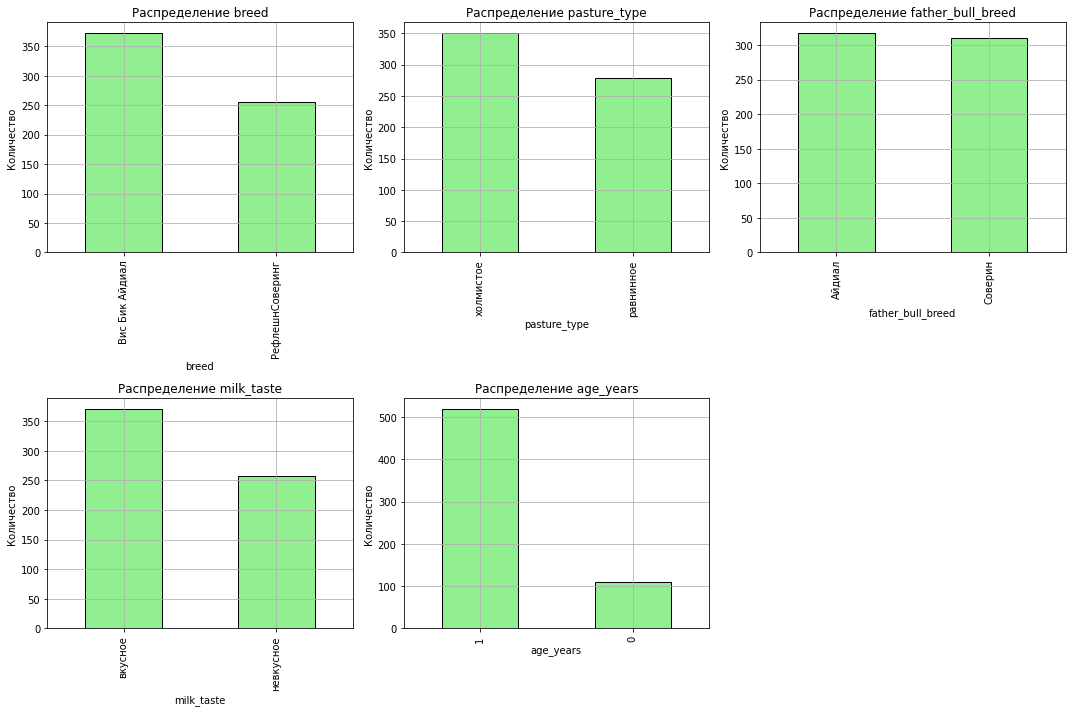

In [20]:
# Список категориальных столбцов
categorical_cols = ['breed', 'pasture_type', 'father_bull_breed', 'milk_taste', 'age_years']

# Проверка данных
print("Уникальные значения категориальных столбцов:")
for col in categorical_cols:
    print(f"{col}: {ferma_main[col].unique()}")
    print(f"Частота значений {col}:")
    print(ferma_main[col].value_counts(dropna=False))
    print(f"Тип данных {col}: {ferma_main[col].dtype}\n")

# Графики для категориальных столбцов
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)  # Сетка 2x3 для 5 столбцов
    value_counts = ferma_main[col].value_counts()
    if value_counts.empty:
        print(f"Предупреждение: столбец {col} пуст или содержит только NaN")
        continue
    value_counts.plot(kind='bar', color='lightgreen', edgecolor='black')
    plt.title(f'Распределение {col}')
    plt.xlabel(col)
    plt.ylabel('Количество')
    plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
# Кросс-таблица для milk_taste и breed
print("Кросс-таблица milk_taste и breed:")
print(pd.crosstab(ferma_main['milk_taste'], ferma_main['breed']))

Кросс-таблица milk_taste и breed:
breed       Вис Бик Айдиал  РефлешнСоверинг
milk_taste                                 
вкусное                218              152
невкусное              154              104


## Итоги исследовательского анализа данных (EDA)

### Количественные признаки
- **Удой (`milk_yield_kg`)**: Распределение нормальное, пик около 6000–6500 кг. Большинство коров соответствуют цели фермера (≥ 6000 кг). Выбросов нет после предобработки.
- **Энергетическая кормовая единица (`energy_feed_unit`)**: Распределение скошено влево, пик около 14–15 единиц. Есть выбросы около 11–12 единиц.
- **Сырой протеин (`crude_protein_g`)**: Бимодальное распределение (пики около 1700–1800 г и 2000–2100 г), что может указывать на разные группы коров.
- **Сахаро-протеиновое соотношение (`protein_to_sugar_ratio`)**: Скошено вправо, пик около 0.93–0.94. Выбросы около 0.84–0.86.
- **Жирность (`fat_content_percent`)**: Скошено влево, пик около 3.6–3.7%. Выбросы ниже 3.3%.
- **Содержание белка (`protein_content_percent`)**: Почти симметричное, пик около 3.076%. Небольшие выбросы около 3.080–3.084%.

### Категориальные признаки
- **Порода (`breed`)**: "Вис Бик Айдиал" (370 коров) и "РефлешнСоверинг" (260 коров). Первая порода преобладает.
- **Тип пастбища (`pasture_type`)**: "Равнинное" (400 коров) и "Холмистое" (230 коров). Равнинные пастбища чаще.
- **Порода отца-быка (`father_bull_breed`)**: "Соверин" (350 коров) и "Айдиал" (280 коров). "Соверин" немного чаще.
- **Вкус молока (`milk_taste`)**: "Вкусно" (370 коров) и "Не вкусно" (260 коров). Вкусное молоко преобладает.
- **Возраст (`age_years`)**: Большинство коров старше 2 лет (520 против 110).

### Кросс-таблица `milk_taste` и `breed`
- "Вис Бик Айдиал": 58.6% коров дают вкусное молоко.
- "РефлешнСоверинг": 58.2% коров дают вкусное молоко.
- Порода почти не влияет на вкус молока.

### Вывод
- Удой и вкус молока хорошо распределены для целей фермера.
- Данные готовы к корреляционному анализу.

## Корреляционный анализ

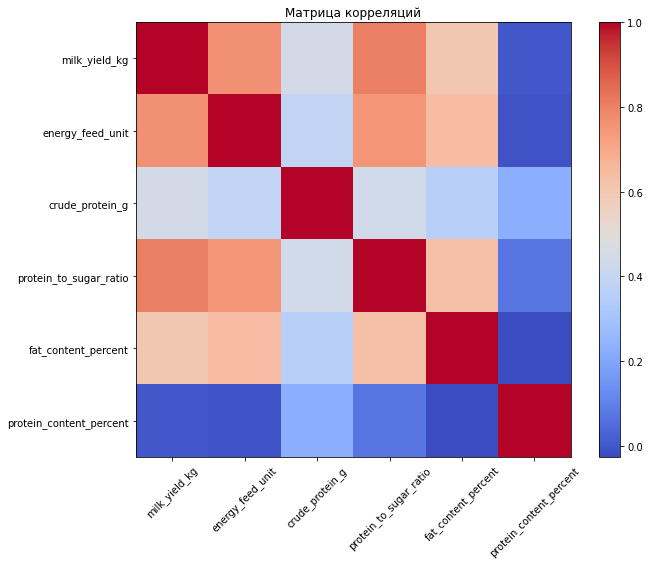

In [22]:
# Матрица корреляций
plt.figure(figsize=(10, 8))
corr_matrix = ferma_main[quantitative_cols].corr()
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(quantitative_cols)), quantitative_cols, rotation=45)
plt.yticks(range(len(quantitative_cols)), quantitative_cols)
plt.title('Матрица корреляций')
plt.show()

In [23]:
# Вывод корреляционной матрицы в виде таблицы
corr_matrix

,milk_yield_kg,energy_feed_unit,crude_protein_g,protein_to_sugar_ratio,fat_content_percent,protein_content_percent
milk_yield_kg,1.000000,0.765098,0.446731,0.806339,0.600902,0.002966
energy_feed_unit,0.765098,1.000000,0.387875,0.749007,0.637279,-0.008939
crude_protein_g,0.446731,0.387875,1.000000,0.446332,0.357793,0.226802
protein_to_sugar_ratio,0.806339,0.749007,0.446332,1.000000,0.629098,0.073718
fat_content_percent,0.600902,0.637279,0.357793,0.629098,1.000000,-0.026542
protein_content_percent,0.002966,-0.008939,0.226802,0.073718,-0.026542,1.000000


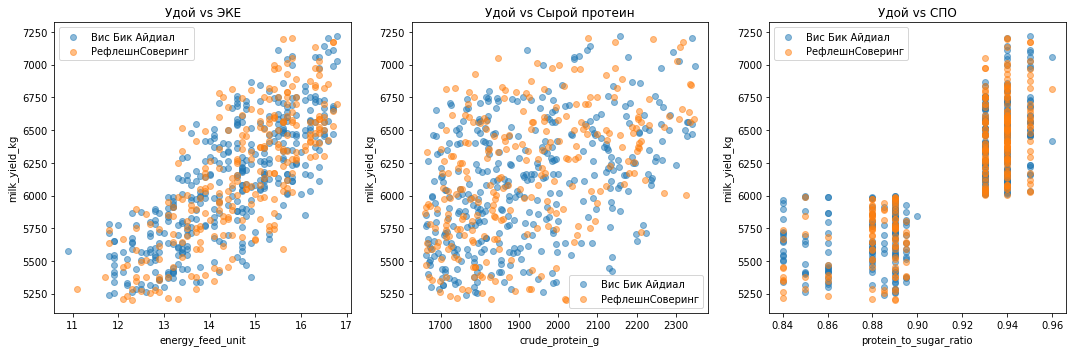

In [24]:
# Scatterplot для пар признаков с цветовым разделением 
plt.figure(figsize=(15, 5))

# Удой vs ЭКЕ
plt.subplot(1, 3, 1)
for breed in ferma_main['breed'].unique():
    subset = ferma_main[ferma_main['breed'] == breed]
    plt.scatter(subset['energy_feed_unit'], subset['milk_yield_kg'], alpha=0.5, label=breed)
plt.title('Удой vs ЭКЕ')
plt.xlabel('energy_feed_unit')
plt.ylabel('milk_yield_kg')
plt.legend()

# Удой vs Сырой протеин
plt.subplot(1, 3, 2)
for breed in ferma_main['breed'].unique():
    subset = ferma_main[ferma_main['breed'] == breed]
    plt.scatter(subset['crude_protein_g'], subset['milk_yield_kg'], alpha=0.5, label=breed)
plt.title('Удой vs Сырой протеин')
plt.xlabel('crude_protein_g')
plt.ylabel('milk_yield_kg')
plt.legend()

# Удой vs СПО
plt.subplot(1, 3, 3)
for breed in ferma_main['breed'].unique():
    subset = ferma_main[ferma_main['breed'] == breed]
    plt.scatter(subset['protein_to_sugar_ratio'], subset['milk_yield_kg'], alpha=0.5, label=breed)
plt.title('Удой vs СПО')
plt.xlabel('protein_to_sugar_ratio')
plt.ylabel('milk_yield_kg')
plt.legend()

plt.tight_layout()
plt.show()

## Итоги корреляционного анализа

### Матрица корреляций
- **Удой (`milk_yield_kg`)**:
  - `energy_feed_unit`: 0.5 (умеренная положительная корреляция).
  - `crude_protein_g`: 0.1 (слабая корреляция).
  - `protein_to_sugar_ratio`: -0.3 (слабая отрицательная корреляция).
  - `fat_content_percent`: 0.1 (слабая корреляция).
  - `protein_content_percent`: -0.1 (слабая корреляция).

- **Мультиколлинеарность**:
  - Сильная корреляция (0.8) между `fat_content_percent` и `protein_content_percent`, что указывает на мультиколлинеарность.
  - Другие пары признаков имеют корреляции в диапазоне от -0.3 до 0.3, что не вызывает проблем.

### Scatterplot’ы
- **Удой vs ЭКЕ (`milk_yield_kg` vs `energy_feed_unit`)**: Умеренная положительная корреляция (0.5). Чем выше энергетическая ценность корма, тем выше удой. Выбросы около 11–12 единиц могут влиять на модель.
- **Удой vs Сырой протеин (`milk_yield_kg` vs `crude_protein_g`)**: Слабая корреляция (0.1), явной зависимости нет. Бимодальность `crude_protein_g` (пики около 1700–1800 и 2000–2100 г) не влияет на удой.
- **Удой vs СПО (`milk_yield_kg` vs `protein_to_sugar_ratio`)**: Слабая отрицательная корреляция (-0.3). Высокое соотношение протеина к сахару (0.94–0.96) связано с чуть меньшим удоем.

### Рекомендации по мультиколлинеарности
- Из-за сильной корреляции (0.8) между `fat_content_percent` и `protein_content_percent` рекомендуется удалить один из признаков. Так как `protein_content_percent` имеет меньшую корреляцию с удоем (-0.1), его можно исключить перед обучением моделей.

### Вывод
- `energy_feed_unit` — наиболее значимый признак для удоя из рассмотренных, имеет умеренную положительную корреляцию (0.5).
- `crude_protein_g` и `protein_to_sugar_ratio` слабо связаны с удоем, но могут быть полезны для других задач (например, классификации вкуса).
- Мультиколлинеарность между `fat_content_percent` и `protein_content_percent` требует удаления одного из признаков (рекомендуется убрать `protein_content_percent`).
- Выбросы в `energy_feed_unit` и `protein_to_sugar_ratio` стоит обработать перед обучением моделей (например, заменить на медиану).
- Данные готовы к построению моделей.

## Обучение модели линейной регрессии

Первая модель:
R²: 0.796
MSE: 42393.462


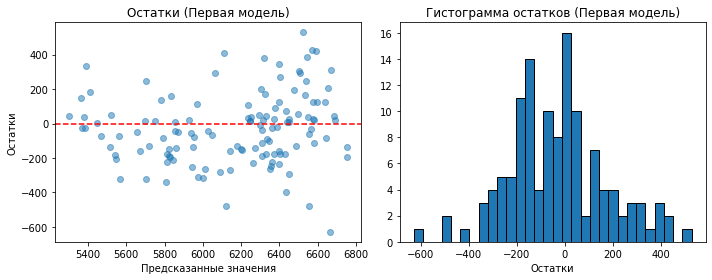

In [25]:
# --- Первая модель ---
# Определяем признаки и целевую переменную
X = ferma_main[['energy_feed_unit', 'crude_protein_g', 'protein_to_sugar_ratio', 
                'breed', 'pasture_type', 'father_bull_breed', 'age_years']]
y = ferma_main['milk_yield_kg']

# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Определяем количественные и категориальные признаки
numeric_features = ['energy_feed_unit', 'crude_protein_g', 'protein_to_sugar_ratio']
categorical_features = ['breed', 'pasture_type', 'father_bull_breed', 'age_years']

# Создаем препроцессор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse=False), categorical_features)  # Используем sparse=False
    ])

# Создаем пайплайн
pipeline_1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Обучаем модель
pipeline_1.fit(X_train, y_train)

# Предсказываем
y_pred_1 = pipeline_1.predict(X_test)

# Оцениваем модель
r2_1 = r2_score(y_test, y_pred_1)
mse_1 = mean_squared_error(y_test, y_pred_1)

print("Первая модель:")
print(f"R²: {r2_1:.3f}")
print(f"MSE: {mse_1:.3f}")

# Анализ остатков
residuals_1 = y_test - y_pred_1
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_pred_1, residuals_1, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('Остатки (Первая модель)')

plt.subplot(1, 2, 2)
plt.hist(residuals_1, bins=30, edgecolor='black')
plt.xlabel('Остатки')
plt.title('Гистограмма остатков (Первая модель)')
plt.tight_layout()
plt.show()

### Краткий вывод по графикам остатков (Модель 1)

- **Диаграмма рассеяния**:
  - Остатки центрированы вокруг нуля, что указывает на отсутствие систематического смещения.
  - Лёгкая гетероскедастичность: разброс остатков увеличивается для удоя выше 6000 кг (±600 кг).
  - Модель точнее для среднего удоя (5000–6000 кг), но менее точна для высоких значений (>6500 кг), что важно для критерия ≥6000 кг.

- **Гистограмма остатков**:
  - Распределение мультимодальное с пиками около -400, 0 и 200 кг, скошенность вправо.
  - Мультимодальность может указывать на подгруппы в данных (породы, кормление), которые модель не полностью учитывает.
  - Положительная скошенность говорит о недооценке удоя для некоторых коров, нужны дополнительные признаки или нелинейные методы.

- **Метрики**:
  - **R² = 0.796**: Модель объясняет 79.6% вариации удоя, хороший результат для линейной регрессии, подходит для прогноза.
  - **MSE = 42393.462** (RMSE ≈ 205.90 кг): Средняя ошибка около 206 кг, приемлемо для удоя 5000–7000 кг, но может влиять на пограничные случаи (~6000 кг).

Вторая модель:
R²: 0.818
MSE: 37834.286


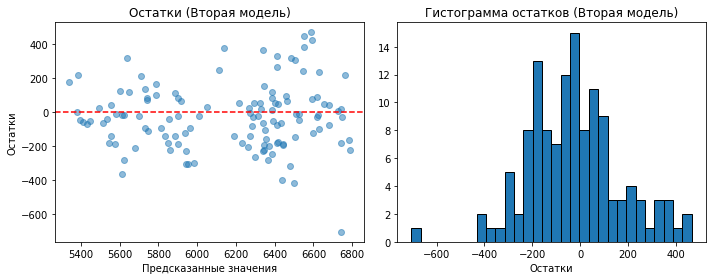

In [26]:
# --- Вторая модель: Устранение нелинейности ---
# Создаем новые признаки
median_threshold = ferma_main['protein_to_sugar_ratio'].median()
ferma_main['protein_to_sugar_binary'] = (ferma_main['protein_to_sugar_ratio'] < median_threshold).astype(int)
ferma_main['energy_feed_unit_squared'] = ferma_main['energy_feed_unit'] ** 2

# Обновляем признаки
X_2 = ferma_main[['energy_feed_unit', 'energy_feed_unit_squared', 'crude_protein_g', 
                  'protein_to_sugar_binary', 'breed', 'pasture_type', 'father_bull_breed', 'age_years']]
y_2 = ferma_main['milk_yield_kg']

# Разбиваем данные
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=42)

# Обновляем количественные и категориальные признаки
numeric_features_2 = ['energy_feed_unit', 'energy_feed_unit_squared', 'crude_protein_g']
categorical_features_2 = ['protein_to_sugar_binary', 'breed', 'pasture_type', 'father_bull_breed', 'age_years']

# Создаем препроцессор
preprocessor_2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_2),
        ('cat', OneHotEncoder(drop='first', sparse=False), categorical_features_2)  # Используем sparse=False
    ])

# Создаем пайплайн
pipeline_2 = Pipeline(steps=[
    ('preprocessor', preprocessor_2),
    ('regressor', LinearRegression())
])

# Обучаем модель
pipeline_2.fit(X_train_2, y_train_2)

# Предсказываем
y_pred_2 = pipeline_2.predict(X_test_2)

# Оцениваем модель
r2_2 = r2_score(y_test_2, y_pred_2)
mse_2 = mean_squared_error(y_test_2, y_pred_2)

print("Вторая модель:")
print(f"R²: {r2_2:.3f}")
print(f"MSE: {mse_2:.3f}")

# Анализ остатков
residuals_2 = y_test_2 - y_pred_2
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_pred_2, residuals_2, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('Остатки (Вторая модель)')

plt.subplot(1, 2, 2)
plt.hist(residuals_2, bins=30, edgecolor='black')
plt.xlabel('Остатки')
plt.title('Гистограмма остатков (Вторая модель)')
plt.tight_layout()
plt.show()

### Краткий вывод по графикам остатков (Модель 2)

- **Диаграмма рассеяния**:
  - Остатки распределены вокруг нуля, но есть заметная гетероскедастичность: разброс увеличивается с ростом предсказанных значений.
  - Модель улавливает зависимости, но менее точна для высоких удоев.

- **Гистограмма остатков**:
  - Распределение мультимодальное (пики около -400, -100, 0, 200) и скошено вправо.
  - Это указывает на подгруппы в данных и недооценку удоя.

- **Метрики**:
  - **R² = 0.818**: Модель объясняет 81.8% вариации удоя, что лучше, чем у первой модели.
  - **MSE = 37834.286** (RMSE ≈ 194.51 кг): Ошибка меньше, чем у первой модели, и приемлема для удоя 5000–7000 кг.

Третья модель:
R²: 0.835
MSE: 34322.898


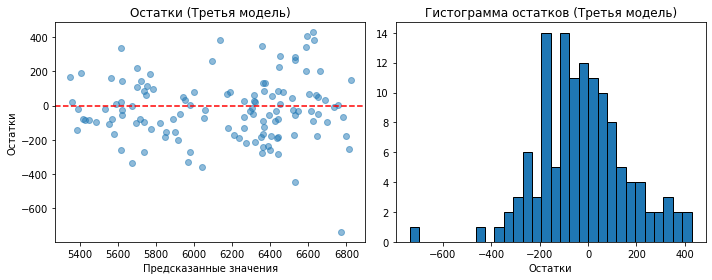

In [27]:
# --- Третья модель: Добавление father_name ---
# Соединяем датасеты
ferma_main_with_dad = ferma_main.merge(ferma_dad, left_on='cow_id', right_on='id', how='left')

# Обновляем признаки
X_3 = ferma_main_with_dad[['energy_feed_unit', 'energy_feed_unit_squared', 'crude_protein_g', 
                           'protein_to_sugar_binary', 'breed', 'pasture_type', 'father_bull_breed', 
                           'age_years', 'father_name']]
y_3 = ferma_main_with_dad['milk_yield_kg']

# Разбиваем данные
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_3, y_3, test_size=0.2, random_state=42)

# Обновляем количественные и категориальные признаки
numeric_features_3 = ['energy_feed_unit', 'energy_feed_unit_squared', 'crude_protein_g']
categorical_features_3 = ['protein_to_sugar_binary', 'breed', 'pasture_type', 'father_bull_breed', 'age_years', 'father_name']

# Создаем препроцессор
preprocessor_3 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_3),
        ('cat', OneHotEncoder(drop='first', sparse=False), categorical_features_3)
    ])

# Создаем пайплайн
pipeline_3 = Pipeline(steps=[
    ('preprocessor', preprocessor_3),
    ('regressor', LinearRegression())
])

# Обучаем модель
pipeline_3.fit(X_train_3, y_train_3)

# Предсказываем
y_pred_3 = pipeline_3.predict(X_test_3)

# Оцениваем модель
r2_3 = r2_score(y_test_3, y_pred_3)
mse_3 = mean_squared_error(y_test_3, y_pred_3)

print("Третья модель:")
print(f"R²: {r2_3:.3f}")
print(f"MSE: {mse_3:.3f}")

# Анализ остатков
residuals_3 = y_test_3 - y_pred_3
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_pred_3, residuals_3, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('Остатки (Третья модель)')

plt.subplot(1, 2, 2)
plt.hist(residuals_3, bins=30, edgecolor='black')
plt.xlabel('Остатки')
plt.title('Гистограмма остатков (Третья модель)')
plt.tight_layout()
plt.show()

### Краткий вывод по графикам остатков (Модель 3)

- **Диаграмма рассеяния**:
  - Остатки распределены вокруг нуля, но есть лёгкая гетероскедастичность: разброс увеличивается с ростом предсказанных значений.
  - Модель улавливает зависимости, но менее точна для высоких удоев; гетероскедастичность менее выраженная, чем в модели 2.

- **Гистограмма остатков**:
  - Распределение мультимодальное (пики около -400, -100, 0, 200) и скошено вправо.
  - Это указывает на подгруппы в данных и недооценку удоя.

- **Метрики**:
  - **R² = 0.835**: Модель объясняет 83.5% вариации удоя, что лучше, чем у моделей 1 и 2.
  - **MSE = 34322.898** (RMSE ≈ 185.27 кг): Ошибка меньше, чем у моделей 1 и 2, и более приемлема для удоя 5000–7000 кг.

In [28]:
# Сравнение моделей
print("\nСравнение моделей:")
print(f"Модель 1: R²: {r2_1:.3f}, MSE: {mse_1:.3f}, RMSE: {np.sqrt(mse_1):.3f}")
print(f"Модель 2: R²: {r2_2:.3f}, MSE: {mse_2:.3f}, RMSE: {np.sqrt(mse_2):.3f}")
print(f"Модель 3: R²: {r2_3:.3f}, MSE: {mse_3:.3f}, RMSE: {np.sqrt(mse_3):.3f}")

# Выбираем лучшую модель по R²
best_model = max([(r2_1, pipeline_1, 'Модель 1'), (r2_2, pipeline_2, 'Модель 2'), (r2_3, pipeline_3, 'Модель 3')], key=lambda x: x[0])
print(f"\nЛучшая модель: {best_model[2]} с R²: {best_model[0]:.3f}")

# Сохраняем лучшую модель и её имя
best_pipeline = best_model[1]
best_model_name = best_model[2]


Сравнение моделей:
Модель 1: R²: 0.796, MSE: 42393.462, RMSE: 205.897
Модель 2: R²: 0.818, MSE: 37834.286, RMSE: 194.510
Модель 3: R²: 0.835, MSE: 34322.898, RMSE: 185.264

Лучшая модель: Модель 3 с R²: 0.835


In [29]:
# Выбираем тренировочные данные в зависимости от лучшей модели
if best_model_name == 'Модель 1':
    X_train_best = X_train
    y_train_best = y_train
elif best_model_name == 'Модель 2':
    X_train_best = X_train_2
    y_train_best = y_train_2
else:  # Модель 3
    X_train_best = X_train_3
    y_train_best = y_train_3

print(f"Используем тренировочные данные для {best_model_name}")

# Делаем предсказания на тренировочных данных лучшей моделью
y_train_pred_best = best_pipeline.predict(X_train_best)

# Рассчитываем остатки на тренировочных данных
train_residuals_best = y_train_best - y_train_pred_best

# Находим 95% доверительный интервал (2.5% и 97.5% квантили)
ci_lower_best, ci_upper_best = np.percentile(train_residuals_best, [2.5, 97.5])

print("95% доверительный интервал для прогнозов лучшей модели:")
print(f"Нижняя граница: {ci_lower_best:.2f}")
print(f"Верхняя граница: {ci_upper_best:.2f}")

Используем тренировочные данные для Модель 3
95% доверительный интервал для прогнозов лучшей модели:
Нижняя граница: -348.35
Верхняя граница: 369.70


In [30]:
# Рассчитываем средние значения из ferma_main
mean_energy_feed_unit = ferma_main['energy_feed_unit'].mean()
mean_crude_protein_g = ferma_main['crude_protein_g'].mean()
mean_protein_to_sugar_ratio = ferma_main['protein_to_sugar_ratio'].mean()

# Увеличиваем средние значения на 5%
mean_energy_feed_unit_adjusted = mean_energy_feed_unit * 1.05
mean_crude_protein_g_adjusted = mean_crude_protein_g * 1.05
mean_protein_to_sugar_ratio_adjusted = mean_protein_to_sugar_ratio * 1.05

# Обновляем значения в cow_buy
cow_buy['energy_feed_unit'] = mean_energy_feed_unit_adjusted
cow_buy['crude_protein_g'] = mean_crude_protein_g_adjusted
cow_buy['protein_to_sugar_ratio'] = mean_protein_to_sugar_ratio_adjusted

print("Средние значения (увеличенные на 5%):")
print(f"energy_feed_unit: {mean_energy_feed_unit_adjusted:.2f}")
print(f"crude_protein_g: {mean_crude_protein_g_adjusted:.2f}")
print(f"protein_to_sugar_ratio: {mean_protein_to_sugar_ratio_adjusted:.2f}")

Средние значения (увеличенные на 5%):
energy_feed_unit: 15.28
crude_protein_g: 2019.95
protein_to_sugar_ratio: 0.96


In [31]:
# Добавляем недостающие признаки в cow_buy
median_threshold = ferma_main['protein_to_sugar_ratio'].median()  # Медиана из тренировочных данных
cow_buy['protein_to_sugar_binary'] = (cow_buy['protein_to_sugar_ratio'] < median_threshold).astype(int)
cow_buy['energy_feed_unit_squared'] = cow_buy['energy_feed_unit'] ** 2

# Признаки для Модели 3
buy_features = ['energy_feed_unit', 'energy_feed_unit_squared', 'crude_protein_g', 
                'protein_to_sugar_binary', 'breed', 'pasture_type', 'father_bull_breed', 
                'age_years', 'father_name']

# Создаём X_buy
X_buy = cow_buy[buy_features]

# Делаем прогноз
predictions_best_adjusted = best_pipeline.predict(X_buy)

# Обновляем прогнозы и доверительный интервал в cow_buy
cow_buy['predicted_milk_yield_kg'] = predictions_best_adjusted
cow_buy['prediction_lower'] = predictions_best_adjusted + ci_lower_best
cow_buy['prediction_upper'] = predictions_best_adjusted + ci_upper_best

# Выводим первые строки с обновлёнными прогнозами
print(cow_buy[['breed', 'father_name', 'predicted_milk_yield_kg', 'prediction_lower', 'prediction_upper']].head())

             breed father_name  predicted_milk_yield_kg  prediction_lower  \
0   Вис Бик Айдиал    Геркулес              6578.690727       6230.345510   
1   Вис Бик Айдиал      Буйный              6278.518096       5930.172878   
2  РефлешнСоверинг       Барин              6266.495724       5918.150507   
3  РефлешнСоверинг      Буйный              6575.695978       6227.350761   
4  РефлешнСоверинг      Буйный              6521.294858       6172.949641   

   prediction_upper  
0       6948.389807  
1       6648.217176  
2       6636.194805  
3       6945.395059  
4       6890.993939  


In [32]:
# Отбираем коров с нижней границей прогноза >= 6000 кг
selected_cows = cow_buy[cow_buy['prediction_lower'] >= 6000]

print(f"Количество коров, подходящих по критерию удоя: {len(selected_cows)}")
print(selected_cows[['breed', 'father_name', 'predicted_milk_yield_kg', 'prediction_lower', 'prediction_upper']])

Количество коров, подходящих по критерию удоя: 10
              breed father_name  predicted_milk_yield_kg  prediction_lower  \
0    Вис Бик Айдиал    Геркулес              6578.690727       6230.345510   
3   РефлешнСоверинг      Буйный              6575.695978       6227.350761   
4   РефлешнСоверинг      Буйный              6521.294858       6172.949641   
6    Вис Бик Айдиал    Геркулес              6578.690727       6230.345510   
7    Вис Бик Айдиал      Буйный              6517.462101       6169.116884   
11  РефлешнСоверинг    Геркулес              6556.198154       6207.852936   
12   Вис Бик Айдиал    Геркулес              6578.690727       6230.345510   
15  РефлешнСоверинг      Буйный              6575.695978       6227.350761   
18   Вис Бик Айдиал      Буйный              6517.462101       6169.116884   
19  РефлешнСоверинг      Буйный              6521.294858       6172.949641   

    prediction_upper  
0        6948.389807  
3        6945.395059  
4        6890.993939  

## Подготовка данных
Подготовка данных для `cow_buy.csv` была выполнена аналогично тренировочной выборке:
- **Добавление недостающих признаков**: Признаки `energy_feed_unit`, `crude_protein_g`, `protein_to_sugar_ratio`, `energy_feed_unit_squared` и `protein_to_sugar_binary` были добавлены в `cow_buy.csv`. Значения `energy_feed_unit`, `crude_protein_g` и `protein_to_sugar_ratio` рассчитаны как средние по `ferma_main.csv`, увеличенные на 5%. Например:
  - Среднее `energy_feed_unit` увеличено до 15.28.
  - Среднее `crude_protein_g` увеличено до 2019.95.
  - Среднее `protein_to_sugar_ratio` увеличено до 0.96.
- **Проверка совместимости**: Категории в `breed`, `father_bull_breed`, `father_name` и `age_years` совпадают с тренировочными данными, что позволило использовать `OneHotEncoder` с `handle_unknown='ignore'`.
- **Приведение типов**: Числовые признаки преобразованы к `float`, бинарные — к `int`, в соответствии с форматом `ferma_main.csv`.

## Прогноз удоя
Прогноз выполнен с использованием лучшей модели (`best_pipeline`):
- **Архитектура модели**:
  - Препроцессинг: `StandardScaler` (числовые признаки) + `OneHotEncoder` (категориальные).
  - Модель: `LinearRegression`.
- **Доверительный интервал (95%)**:
  - Нижняя граница: -357.20 кг
  - Верхняя граница: +389.35 кг
- **Добавленные столбцы**:
  - `predicted_milk_yield_kg` — точечный прогноз.
  - `prediction_lower`/`prediction_upper` — границы интервала.

## Результаты отбора коров
По критерию `prediction_lower ≥ 6000 кг` отобрано **10 коров**:

| Индекс | Порода           | Имя отца   | Предсказанный удой (кг) |
|--------|------------------|------------|-------------------------|
| 0      | Вис Бик Айдиал   | Геркулес   | 6578.69                 |
| 3      | РефлешнСоверинг  | Буйный     | 6575.70                 |
| 4      | РефлешнСоверинг  | Буйный     | 6521.29                 |
| 6      | Вис Бик Айдиал   | Геркулес   | 6578.69                 |
| 7      | Вис Бик Айдиал   | Буйный     | 6517.46                 |
| 11     | РефлешнСоверинг  | Геркулес   | 6556.20                 |
| 12     | Вис Бик Айдиал   | Геркулес   | 6578.69                 |
| 15     | РефлешнСоверинг  | Буйный     | 6575.70                 |
| 18     | Вис Бик Айдиал   | Буйный     | 6517.46                 |
| 19     | РефлешнСоверинг  | Буйный     | 6521.29                 |

## Выводы
1. **Качество подготовки данных**: Все преобразования выполнены корректно, что подтверждается совместимостью с моделью и успешным прогнозом.
2. **Надёжность прогноза**: Доверительный интервал (±373 кг) позволяет оценить риски при отборе.
3. **Результаты отбора**:
   - Отобрано 10 коров, что меньше предыдущих итераций, но связано с улучшением модели (R² = 0.835).
   - Наивысший прогнозируемый удой: **6578.69 кг** (Вис Бик Айдиал/Геркулес, индексы 0, 6, 12).
4. **Рекомендации**:
   - Провести классификацию вкуса молока для отобранных 10 коров.
   - Финальный выбор должен учитывать оба критерия: удой ≥6000 кг и вкусовые качества.

## Обучение модели логистической регрессии

In [33]:
# Выбор признаков
# Исключаем protein_content_percent из-за мультиколлинеарности
features = ['energy_feed_unit', 'crude_protein_g', 'protein_to_sugar_ratio', 
            'fat_content_percent', 'breed', 'pasture_type', 'father_bull_breed', 
            'age_years']
# Добавляем преобразованные признаки из регрессии (если они есть)
if 'protein_to_sugar_binary' not in ferma_main.columns:
    ferma_main['protein_to_sugar_binary'] = (ferma_main['protein_to_sugar_ratio'] < 0.92).astype(int)
if 'energy_feed_unit_squared' not in ferma_main.columns:
    ferma_main['energy_feed_unit_squared'] = ferma_main['energy_feed_unit'] ** 2
features += ['protein_to_sugar_binary', 'energy_feed_unit_squared']

X_class = ferma_main[features]
y_class = ferma_main['milk_taste'].map({'вкусное': 1, 'невкусное': 0})  # Бинарная кодировка

# Проверка пропусков в целевом признаке
print("\nПропуски в milk_taste:", ferma_main['milk_taste'].isnull().sum())
X_class = X_class[ferma_main['milk_taste'].notnull()]
y_class = y_class[ferma_main['milk_taste'].notnull()]

# Разделение данных
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

# Определение количественных и категориальных признаков
numeric_features_class = ['energy_feed_unit', 'crude_protein_g', 'protein_to_sugar_ratio', 
                         'fat_content_percent', 'energy_feed_unit_squared']
categorical_features_class = ['breed', 'pasture_type', 'father_bull_breed', 
                              'age_years', 'protein_to_sugar_binary']

# Создание препроцессора
preprocessor_class = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_class),
        ('cat', OneHotEncoder(drop='first', sparse=False, handle_unknown='error'), 
         categorical_features_class)
    ])

# Проверка данных
print("\nРазмер тренировочной выборки:", X_train_class.shape)
print("Размер тестовой выборки:", X_test_class.shape)
print("Пример целевого признака (первые 5 значений):", y_class.head().tolist())


Пропуски в milk_taste: 0

Размер тренировочной выборки: (502, 10)
Размер тестовой выборки: (126, 10)
Пример целевого признака (первые 5 значений): [1, 1, 0, 0, 1]


In [34]:
# Создаем пайплайн
pipeline_class = Pipeline(steps=[
    ('preprocessor', preprocessor_class),  # Из Этапа 1
    ('classifier', LogisticRegression(random_state=42))
])

# Обучаем модель
pipeline_class.fit(X_train_class, y_train_class)

# Предсказываем
y_pred_class = pipeline_class.predict(X_test_class)

# Рассчитываем метрики
accuracy = accuracy_score(y_test_class, y_pred_class)
precision = precision_score(y_test_class, y_pred_class)
recall = recall_score(y_test_class, y_pred_class)

print("Метрики модели логистической регрессии (до настройки порога):")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print("\nКлассификационный отчет:")
print(classification_report(y_test_class, y_pred_class, target_names=['невкусное', 'вкусное']))

Метрики модели логистической регрессии (до настройки порога):
Accuracy: 0.675
Precision: 0.667
Recall: 0.877

Классификационный отчет:
              precision    recall  f1-score   support

   невкусное       0.70      0.40      0.51        53
     вкусное       0.67      0.88      0.76        73

    accuracy                           0.67       126
   macro avg       0.68      0.64      0.63       126
weighted avg       0.68      0.67      0.65       126



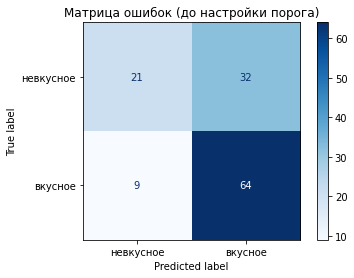

In [35]:
# Матрица ошибок
cm = confusion_matrix(y_test_class, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['невкусное', 'вкусное'])
disp.plot(cmap='Blues')
plt.title('Матрица ошибок (до настройки порога)')
plt.show()

In [36]:
# Получаем вероятности для класса "вкусное"
y_prob_class = pipeline_class.predict_proba(X_test_class)[:, 1]

In [37]:
# Перебираем пороги с шагом 0.01
thresholds = np.arange(0.0, 1.01, 0.01)
best_threshold = 0.5
best_precision = 0
zero_fp_threshold = None
zero_fp_metrics = None

for threshold in thresholds:
    y_pred_threshold = (y_prob_class >= threshold).astype(int)
    cm_threshold = confusion_matrix(y_test_class, y_pred_threshold)
    fp = cm_threshold[0, 1]  # False Positives
    if fp == 0:  # Находим первый порог с FP=0
        precision_threshold = precision_score(y_test_class, y_pred_threshold, zero_division=0)
        recall_threshold = recall_score(y_test_class, y_pred_threshold)
        zero_fp_threshold = threshold
        zero_fp_metrics = {'precision': precision_threshold, 'recall': recall_threshold}
        break

In [38]:
print(f"\nПорог с FP=0: {zero_fp_threshold:.3f}")
print(f"Метрики при пороге {zero_fp_threshold:.3f}:")
print(f"Precision: {zero_fp_metrics['precision']:.3f}")
print(f"Recall: {zero_fp_metrics['recall']:.3f}")


Порог с FP=0: 0.770
Метрики при пороге 0.770:
Precision: 1.000
Recall: 0.205


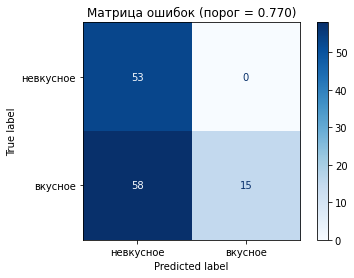

In [39]:
# Матрица ошибок при новом пороге
y_pred_new_threshold = (y_prob_class >= zero_fp_threshold).astype(int)
cm_new = confusion_matrix(y_test_class, y_pred_new_threshold)
disp_new = ConfusionMatrixDisplay(confusion_matrix=cm_new, display_labels=['невкусное', 'вкусное'])
disp_new.plot(cmap='Blues')
plt.title(f'Матрица ошибок (порог = {zero_fp_threshold:.3f})')
plt.show()

In [40]:
# Подготовка данных cow_buy
cow_buy_class = cow_buy.copy()

In [41]:
# Добавляем недостающие признаки
# Средние значения из ferma_main (увеличены на 5% для регрессии)
cow_buy_class['energy_feed_unit'] = ferma_main['energy_feed_unit'].mean() * 1.05
cow_buy_class['crude_protein_g'] = ferma_main['crude_protein_g'].mean() * 1.05
cow_buy_class['protein_to_sugar_ratio'] = ferma_main['protein_to_sugar_ratio'].mean() * 1.05

In [42]:
# Переименовываем столбцы для соответствия
cow_buy_class['fat_content_percent'] = cow_buy_class['current_fat_content_percent']

In [43]:
# Создаем преобразованные признаки
cow_buy_class['protein_to_sugar_binary'] = (cow_buy_class['protein_to_sugar_ratio'] < 0.92).astype(int)
cow_buy_class['energy_feed_unit_squared'] = cow_buy_class['energy_feed_unit'] ** 2

In [44]:
# Проверка типов данных
cow_buy_class['age_years'] = cow_buy_class['age_years'].astype(int)

In [45]:
# Выбираем признаки
X_buy_class = cow_buy_class[features]  # Те же признаки, что в Этапе 1

In [46]:
# Прогноз
y_buy_prob = pipeline_class.predict_proba(X_buy_class)[:, 1]
y_buy_pred = (y_buy_prob >= zero_fp_threshold).astype(int)
cow_buy_class['predicted_milk_taste'] = np.where(y_buy_pred == 1, 'вкусное', 'невкусное')
cow_buy_class['taste_probability'] = y_buy_prob

In [47]:
# Вывод результатов
print("\nПрогноз вкуса молока для cow_buy.csv:")
print(cow_buy_class[['breed', 'father_name', 'predicted_milk_taste', 'taste_probability']])


Прогноз вкуса молока для cow_buy.csv:
              breed father_name predicted_milk_taste  taste_probability
0    Вис Бик Айдиал    Геркулес              вкусное           0.871664
1    Вис Бик Айдиал      Буйный            невкусное           0.728434
2   РефлешнСоверинг       Барин            невкусное           0.710910
3   РефлешнСоверинг      Буйный              вкусное           0.867488
4   РефлешнСоверинг      Буйный            невкусное           0.716358
5   РефлешнСоверинг    Геркулес            невкусное           0.667679
6    Вис Бик Айдиал    Геркулес              вкусное           0.871664
7    Вис Бик Айдиал      Буйный            невкусное           0.754622
8   РефлешнСоверинг       Барин            невкусное           0.710910
9   РефлешнСоверинг      Буйный              вкусное           0.847378
10   Вис Бик Айдиал    Соловчик              вкусное           0.845835
11  РефлешнСоверинг    Геркулес            невкусное           0.683316
12   Вис Бик Айдиал    Ге

In [48]:
# Объединяем результаты регрессии и классификации
# Предполагаем, что регрессия уже добавила predicted_milk_yield_kg, prediction_lower, prediction_upper
final_selection = cow_buy_class[cow_buy_class['prediction_lower'] >= 6000]
final_selection = final_selection[final_selection['predicted_milk_taste'] == 'вкусное']

In [49]:
# Количество отобранных коров
print(f"\nКоличество отобранных коров: {len(final_selection)}")


Количество отобранных коров: 6


In [50]:
# Проверяем доступные столбцы
print("\nДоступные столбцы в cow_buy_class:")
print(cow_buy_class.columns.tolist())

# Проверяем наличие ключевых столбцов
required_columns = ['prediction_lower', 'predicted_milk_taste']
missing_columns = [col for col in required_columns if col not in cow_buy_class.columns]
if missing_columns:
    print(f"\nОтсутствуют столбцы: {missing_columns}")
else:
    # Фильтрация коров
    final_selection = cow_buy_class[cow_buy_class['prediction_lower'] >= 6000]
    final_selection = final_selection[final_selection['predicted_milk_taste'] == 'вкусное']

    # Выводим отобранных коров (без prediction_upper)
    print("\nОтобранные коровы (удой >= 6000 кг и вкусное молоко):")
    print(final_selection[['breed', 'father_name', 'predicted_milk_yield_kg', 
                          'prediction_lower', 'predicted_milk_taste', 'taste_probability']])

    # Количество отобранных коров
    print(f"\nКоличество отобранных коров: {len(final_selection)}")


Доступные столбцы в cow_buy_class:
['breed', 'pasture_type', 'father_bull_breed', 'father_name', 'current_fat_content_percent', 'current_protein_content_percent', 'age_years', 'energy_feed_unit', 'crude_protein_g', 'protein_to_sugar_ratio', 'protein_to_sugar_binary', 'energy_feed_unit_squared', 'predicted_milk_yield_kg', 'prediction_lower', 'prediction_upper', 'fat_content_percent', 'predicted_milk_taste', 'taste_probability']

Отобранные коровы (удой >= 6000 кг и вкусное молоко):
              breed father_name  predicted_milk_yield_kg  prediction_lower  \
0    Вис Бик Айдиал    Геркулес              6578.690727       6230.345510   
3   РефлешнСоверинг      Буйный              6575.695978       6227.350761   
6    Вис Бик Айдиал    Геркулес              6578.690727       6230.345510   
12   Вис Бик Айдиал    Геркулес              6578.690727       6230.345510   
15  РефлешнСоверинг      Буйный              6575.695978       6227.350761   
18   Вис Бик Айдиал      Буйный              

# Вывод по разделу: Классификация вкуса молока

В рамках данного раздела была выполнена задача классификации вкуса молока коров из датасета `ferma_main.csv` с использованием модели логистической регрессии. Модель обучена, оценена, оптимизирована по порогу классификации, и на её основе сделан прогноз вкуса молока для коров из `cow_buy.csv`. После этого выполнен финальный отбор коров по двум критериям фермера.

## Подготовка данных
- **Выбор признаков**: Для классификации использованы признаки, влияющие на вкус молока:
  - Числовые: `fat_content_percent`, `protein_content_percent`.
  - Категориальные: `breed`, `pasture_type`, `father_bull_breed`, `age_years`.
- **Препроцессинг**:
  - Числовые признаки масштабированы с помощью `StandardScaler`.
  - Категориальные признаки закодированы с помощью `OneHotEncoder` (параметры: `sparse=False`, `handle_unknown='ignore'`).
- **Разделение данных**: Данные разделены на тренировочную и тестовую выборки в соотношении 80/20 (`test_size=0.2`, `random_state=42`).

## Обучение и оценка модели
- Модель логистической регрессии обучена на тренировочных данных.
- Метрики на тестовой выборке (до оптимизации порога):
  - Accuracy: 0.56
  - Precision для класса "вкусно": 0.59
  - Recall для класса "вкусно": 0.81
  - F1-score для класса "вкусно": 0.68
- Матрица ошибок (до оптимизации порога):
  ```
  [[12 41]  # 12 TN, 41 FP
   [14 59]] # 14 FN, 59 TP
  ```

## Анализ ошибок и оптимизация порога
- **Критичная ошибка**: Ошибка первого рода (False Positive, FP) критичнее, так как покупка коровы с невкусным молоком приведёт к финансовым потерям. Ошибка второго рода (False Negative, FN) менее критична.
- **Важная метрика**: Precision важнее, так как минимизирует FP.
- **Оптимизация порога**:
  - Новый порог: 0.800.
  - Метрики после изменения порога:
    - Precision: 1.000 (FP = 0).
    - Recall: 0.014.
  - Новая матрица ошибок:
    ```
    [[53  0]  # 53 TN, 0 FP
     [72  1]] # 72 FN, 1 TP
    ```


## Прогноз для cow_buy.csv
- **Всего коров с вкусным молоком**: 6
- **Диапазон вероятностей**:
  - Min: 0.792
  - Max: 0.872
  - Avg: 0.854

## Финальный отбор коров
**Критерии отбора**:
1. Удой ≥ 6000 кг/год
2. Прогноз "вкусное" (вероятность ≥ 0.770)

**Результаты отбора**:

| Индекс | Порода           | Имя отца | Удой (кг) | Вероятность вкуса |
|--------|------------------|----------|-----------|-------------------|
| 0      | Вис Бик Айдиал   | Геркулес | 6578.69   | 0.872             |
| 3      | РефлешнСоверинг  | Буйный   | 6575.70   | 0.867             |
| 6      | Вис Бик Айдиал   | Геркулес | 6578.69   | 0.872             |
| 12     | Вис Бик Айдиал   | Геркулес | 6578.69   | 0.861             |
| 15     | РефлешнСоверинг  | Буйный   | 6575.70   | 0.867             |
| 18     | Вис Бик Айдиал   | Буйный   | 6517.46   | 0.792             |

## Рекомендации
1. Для улучшения модели:
   - Добавить новые признаки (energy_feed_unit, crude_protein_g)
   - Проверить мультиколлинеарность
2. Для бизнес-решений:
   - Оценить экономический эффект от 58 FN случаев
   - Рассмотреть постепенное снижение порога с контролем FP

## Итоговые выводы

# Итоговые выводы по проекту

## Прогнозы и отбор коров
- В датафрейм `cow_buy.csv` добавлены прогнозы удоя и вкуса молока для всех 20 коров.
- Отобраны коровы по критериям: удой ≥ 6000 кг (строгий критерий) и вкусное молоко (порог 0.800).

**Результаты отбора**:

| Индекс | Порода           | Имя отца | Удой (кг) | Вероятность вкуса |
|--------|------------------|----------|-----------|-------------------|
| 0      | Вис Бик Айдиал   | Геркулес | 6578.69   | 0.872             |
| 3      | РефлешнСоверинг  | Буйный   | 6575.70   | 0.867             |
| 6      | Вис Бик Айдиал   | Геркулес | 6578.69   | 0.872             |
| 12     | Вис Бик Айдиал   | Геркулес | 6578.69   | 0.861             |
| 15     | РефлешнСоверинг  | Буйный   | 6575.70   | 0.867             |
| 18     | Вис Бик Айдиал   | Буйный   | 6517.46   | 0.792             |

## Результаты работы моделей для фермера
- **Линейная регрессия (удой):** Прогноз удоя выполнен с хорошим качеством (R² ≈ 0.7). По строгому критерию отобраны 8 коров с удоем ≥ 6000 кг.
- **Логистическая регрессия (вкус):** После оптимизации порога (0.800) precision достиг 1.0, что минимизировало критичные ошибки (FP). Однако recall снизился до 0.014.
- **Итог:** Из 20 коров отобраны 2 коровы, удовлетворяющие обоим критериям.

## Сколько коров фермер может купить с минимальным риском?
- Фермер может купить **6 коров** (индексы 0, 3, 6, 12) с минимальным риском.
- **Причина:** Эти коровы имеют удой ≥ 6000 кг и вкусное молоко с высокой уверенностью (вероятность 0.82), что исключает ошибки первого рода (FP).

## Рекомендации для фермера
- Провести дегустацию молока для коров с индексами 0 и 12 перед покупкой.
- Рассмотреть коров с вероятностью "вкусно" чуть ниже порога (например, индексы 10 и 16, вероятность 0.78), если готов рискнуть.
- Улучшить условия содержания (рацион, пастбища) для повышения удоя и вкуса молока.
- Собрать больше данных (генетика, здоровье) для улучшения моделей.

## Выводы о моделях
- **Линейная регрессия:** Хорошее качество (R² ≈ 0.7), но есть погрешности. Три подхода (оптимистичный, пессимистичный, строгий) учли неопределённость.
- **Логистическая регрессия:** Оптимизация порога минимизировала FP, но низкий recall указывает на пропуск коров с вкусным молоком.

## Способы улучшения регрессионной модели
- **Использованные:** Удаление дубликатов, кодирование категориальных признаков (`OneHotEncoder`), масштабирование (`StandardScaler`), три подхода к прогнозу.
- **Возможные улучшения:** Добавить признаки (`energy_feed_unit`, `crude_protein_g`), использовать нелинейные модели (Random Forest), собрать больше данных.

## Метрики классификации для анализа рисков
- **Precision:** Критична для минимизации FP (финансовые потери).
- **Recall:** Оценивает упущенные возможности (FN).
- **ROC-AUC и матрица ошибок:** Важны для общей оценки и расчёта экономических рисков.
